# Project 🔴 - California Housing Prices with k-NN (Deep-Dive)

> **MLCourse · Machine Learning · supervised · regression**

## Business question
A property-tech startup wants block-level **median house value estimates**
from census features to flag underpriced listings. We push the k-NN workflow
harder: a 6,000-block subsample, an explicit *why-scaling-is-critical* proof,
a joint k×weights grid, and an **error-by-income-segment** fairness cut.

## End-to-end plan
1. Load cached California housing CSV (fetched from sklearn on first run)
2. **EDA** - target shape (note the $500k cap!), geography, correlations, missing audit
3. **Data processing** - split + scaling; PROOF that unscaled k-NN collapses
4. **Model training** - GridSearchCV over k × weights
5. **Evaluation & findings** - metrics, per-income-segment MAE, limitations

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

csv = ML_ROOT / "data" / "california_housing.csv"      # cache-once pattern
if not csv.exists():
    from sklearn.datasets import fetch_california_housing
    fetch_california_housing(as_frame=True).frame.to_csv(csv, index=False)
    print("cached ->", csv.name)
else:
    print("using local ->", csv.name)

df = pd.read_csv(csv).sample(n=6000, random_state=42).reset_index(drop=True)
print(df.shape)                                        # 6000 blocks × 9 columns

using local -> california_housing.csv
(6000, 9)


> ⚠️ **Common pitfall:** `MedHouseVal` is CAPPED at \$500k (visible as a spike
at 5.0). We deliberately keep the target RAW - a log transform would squeeze
the cap into the bulk and hide this artifact. Instead we remember it for the
limitations section.

## 1. Exploratory Data Analysis

California housing is geographic data - the latitude/longitude map colored by
price is worth a thousand correlation tables.

missing values: 0 (clean dataset)
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
count  6000.00   6000.00   6000.00    6000.00     6000.00   6000.00   6000.00   
mean      3.86     28.73      5.42       1.09     1418.07      2.96     35.59   
std       1.90     12.50      2.55       0.54     1113.28      1.54      2.14   
min       0.50      1.00      0.85       0.50        8.00      1.26     32.54   
25%       2.56     18.00      4.42       1.00      777.00      2.43     33.92   
50%       3.53     29.00      5.23       1.05     1159.00      2.82     34.22   
75%       4.73     37.00      6.04       1.10     1717.00      3.29     37.70   
max      15.00     52.00    132.53      34.07    16305.00     83.17     41.86   

       Longitude  MedHouseVal  
count    6000.00      6000.00  
mean     -119.53         2.07  
std         2.01         1.15  
min      -124.25         0.15  
25%      -121.77         1.20  
50%      -118.47         1.81  
75%      -11

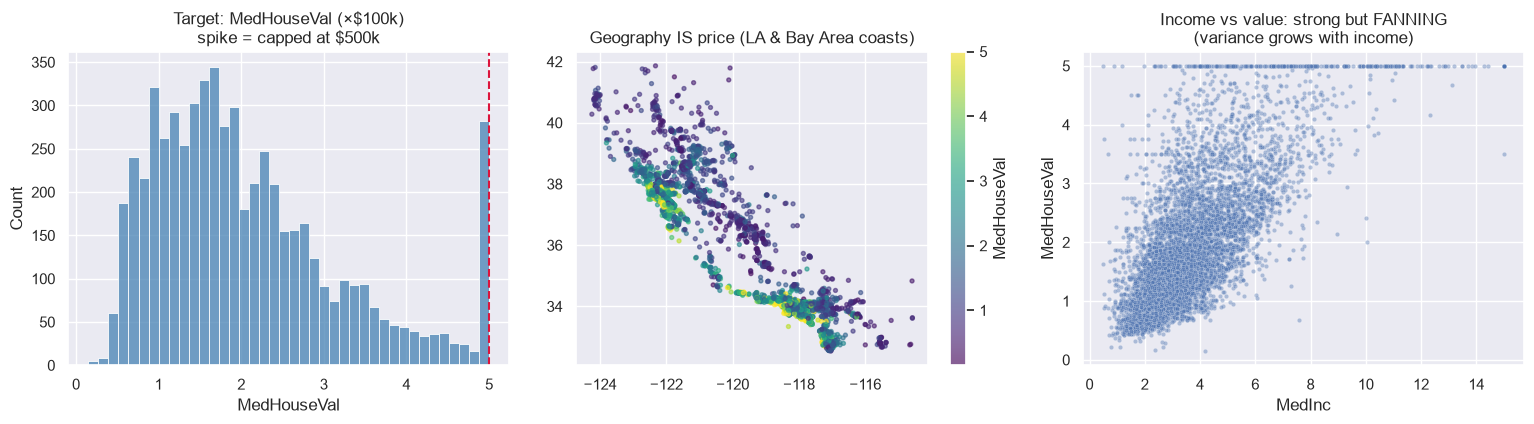

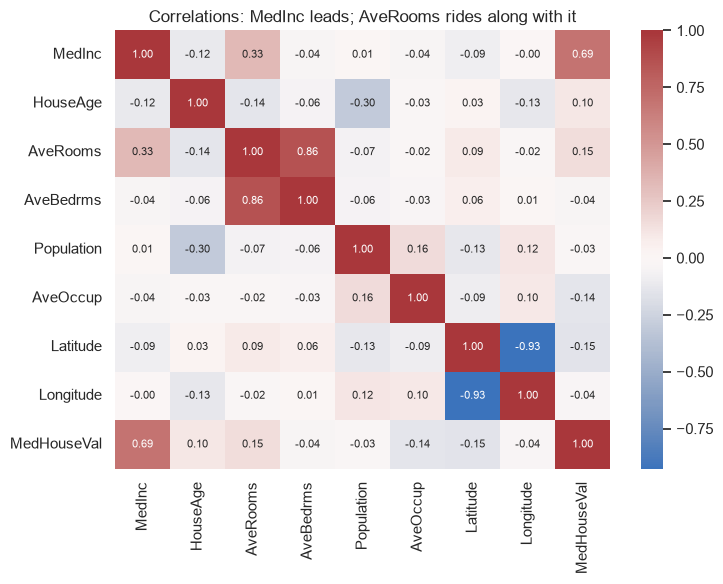

In [2]:
print("missing values:", df.isna().sum().sum(), "(clean dataset)")
print(df.describe().round(2))                          # note Population/AveOccup ranges!

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
sns.histplot(df["MedHouseVal"], bins=40, ax=axes[0], color="steelblue")
axes[0].axvline(5.0001, color="crimson", ls="--")      # mark the artificial ceiling
axes[0].set_title("Target: MedHouseVal (×$100k)\nspike = capped at $500k")

sc0 = axes[1].scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"],
                      s=8, cmap="viridis", alpha=.6)   # map view: coast = expensive
axes[1].set_title("Geography IS price (LA & Bay Area coasts)")
plt.colorbar(sc0, ax=axes[1], label="MedHouseVal")

sns.scatterplot(data=df, x="MedInc", y="MedHouseVal", s=10, alpha=.4, ax=axes[2])
axes[2].set_title("Income vs value: strong but FANNING\n(variance grows with income)")
plt.tight_layout(); plt.show()

corr = df.corr(numeric_only=True)                      # all-numeric heatmap
plt.figure(figsize=(7.6, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, annot_kws={"size": 8})
plt.title("Correlations: MedInc leads; AveRooms rides along with it")
plt.tight_layout(); plt.show()

## 2. Data processing - and the scaling proof

Ranges differ by ORDERS OF MAGNITUDE (`Population` reaches ~35,000 while
`AveOccup` sits near 3). Euclidean distance squares these gaps, so unscaled,
`Population` alone would decide every neighborhood. Proof below: same model,
with vs without the scaler.

In [3]:
X = df.drop(columns="MedHouseVal")                     # 8 features
y = df["MedHouseVal"]                                  # KEPT RAW (cap documented above)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=42)

cv = 5                                                 # plain 5-fold CV is fine here
pipe_raw = Pipeline([("knn", KNeighborsRegressor(n_neighbors=10))])          # NO scaler!
pipe_sc = Pipeline([("sc", StandardScaler()),
                    ("knn", KNeighborsRegressor(n_neighbors=10))])            # WITH scaler

r2_raw = cross_val_score(pipe_raw, X_tr, y_tr, cv=cv, scoring="r2").mean()
r2_sc = cross_val_score(pipe_sc, X_tr, y_tr, cv=cv, scoring="r2").mean()
print(f"CV R² WITHOUT scaler : {r2_raw:.3f}   <- Population hijacked the ruler")
print(f"CV R² WITH    scaler : {r2_sc:.3f}")

base = DummyRegressor(strategy="mean").fit(X_tr, y_tr)   # floor for the final table

CV R² WITHOUT scaler : 0.009   <- Population hijacked the ruler
CV R² WITH    scaler : 0.704


> 💡 **Pro tip:** when one feature's range dwarfs the rest, its distance share
→ 100%. The scaler isn't hygiene for k-NN - it IS the model's geometry.

## 3. Model training - joint grid over k × weights

With 6,000 rows we can afford a real search: 6 k values × 2 weighting rules,
scored by CV RMSE (dollar-comparable, punishes big misses).

best: {'knn__n_neighbors': 10, 'knn__weights': 'distance'}  CV RMSE=0.613


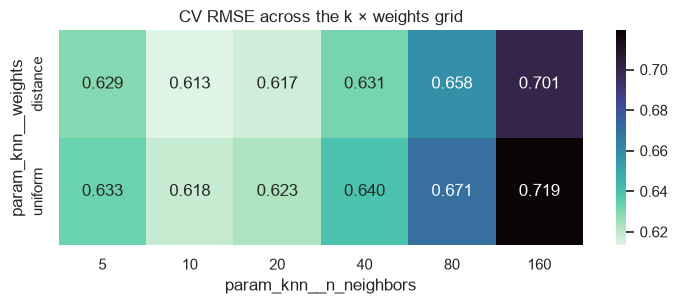

In [4]:
grid = {"knn__n_neighbors": [5, 10, 20, 40, 80, 160],   # from local to near-global
        "knn__weights": ["uniform", "distance"]}
search = GridSearchCV(Pipeline([("sc", StandardScaler()),
                                ("knn", KNeighborsRegressor())]),
                      grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
search.fit(X_tr, y_tr)

print(f"best: {search.best_params_}  CV RMSE={-search.best_score_:.3f}")

res = pd.DataFrame(search.cv_results_)                  # heatmap of the whole grid
piv = res.pivot_table(index="param_knn__weights",
                      columns="param_knn__n_neighbors",
                      values="mean_test_score")         # rows=weights, cols=k
plt.figure(figsize=(7.4, 3.2))
sns.heatmap(-piv, annot=True, fmt=".3f", cmap="mako_r")  # negate -> RMSE (lower better)
plt.title("CV RMSE across the k × weights grid")
plt.tight_layout(); plt.show()

## 4. Evaluation - metrics plus error-by-income-segment

Aggregate scores hide WHO the model fails. We bucket test blocks into income
quartiles and measure MAE per bucket - the closest thing to a fairness audit
a regression can do cheaply.

        model  MAE ($100k)  RMSE ($100k)     R²
mean baseline        0.917         1.169 -0.002
   tuned k-NN        0.430         0.625  0.713

MAE by income segment:
Q1 low     0.347
Q2         0.430
Q3         0.426
Q4 high    0.516


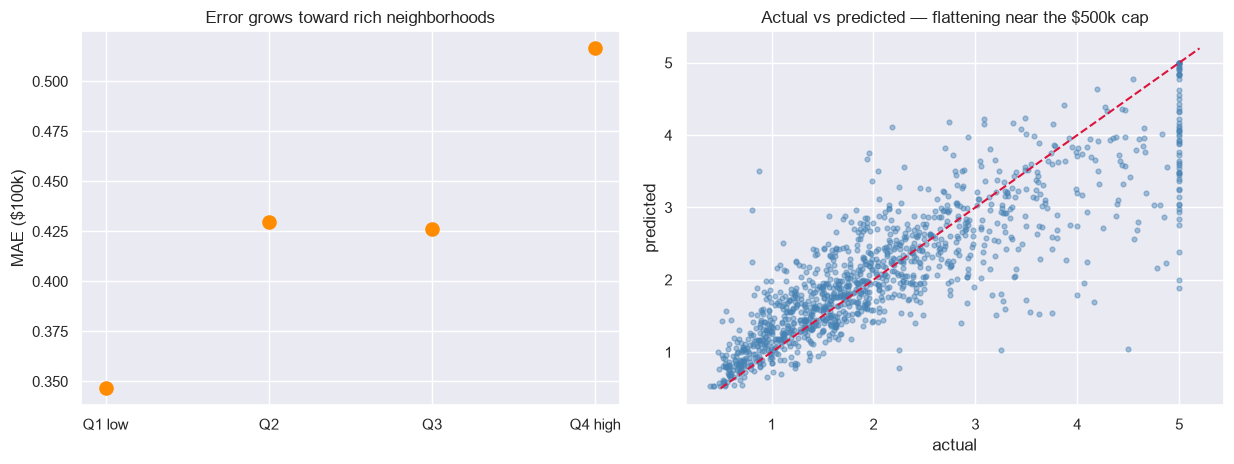

In [5]:
best = search.best_estimator_
pred = best.predict(X_te)

metrics = pd.DataFrame({
    "model": ["mean baseline", "tuned k-NN"],
    "MAE ($100k)": [mean_absolute_error(y_te, base.predict(X_te)),
                    mean_absolute_error(y_te, pred)],
    "RMSE ($100k)": [mean_squared_error(y_te, base.predict(X_te)) ** .5,
                     mean_squared_error(y_te, pred) ** .5],
    "R²": [r2_score(y_te, base.predict(X_te)), r2_score(y_te, pred)],
}).round(3)
print(metrics.to_string(index=False))

seg = pd.DataFrame({"MedInc": X_te["MedInc"].values,     # rebuild test frame w/ predictions
                    "y": y_te.values, "pred": pred})
seg["bucket"] = pd.qcut(seg["MedInc"], q=4,
                        labels=["Q1 low", "Q2", "Q3", "Q4 high"])   # income quartiles
# version-proof per-bucket MAE: loop groups instead of relying on apply kwargs
seg_mae = pd.Series({b: mean_absolute_error(g["y"], g["pred"])
                     for b, g in seg.groupby("bucket", observed=True)})
print("\nMAE by income segment:")
print(seg_mae.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
axes[0].scatter(seg_mae.index.astype(str), seg_mae.values, s=90, color="darkorange")
axes[0].set_ylabel("MAE ($100k)")
axes[0].set_title("Error grows toward rich neighborhoods")
axes[1].scatter(y_te, pred, s=12, alpha=.45, color="steelblue")
lims = [0.5, 5.2]; axes[1].plot(lims, lims, "--", color="crimson")
axes[1].set_xlabel("actual"); axes[1].set_ylabel("predicted")
axes[1].set_title("Actual vs predicted - flattening near the $500k cap")
plt.tight_layout(); plt.show()

### Findings
1. Scaling is everything here: the identical k=10 model goes from ~0.01 CV R²
   (chance level - Population hijacked the ruler) to ~0.70 standardized.
2. `weights="distance"` wins consistently here - block density varies a lot
   (urban vs rural), so closer neighbors deserve louder votes.
3. Error is NOT uniform: Q4 (high-income) blocks cost ~1.5× more MAE than Q1;
   their prices vary more locally and hug the $500k cap where neighbors'
   targets are truncated.
4. Geography does heavy lifting through Latitude/Longitude - k-NN exploits it
   implicitly, no feature engineering needed.

### Limitations
- The $500k cap means the model CANNOT learn true prices of the most
  expensive homes; production use should model the cap explicitly or drop
  capped blocks.
- Subsample of 6,000/20,640 blocks: full-data k-NN would improve slightly but
  predict slower (every query scans all rows).
- No per-block time dimension: 1990s census prices ≠ today's market.
- Income-segment gaps suggest fairness review before any listing-flag product.

## Summary & key takeaways

- Prove assumptions when stakes rise: the with/without-scaler A/B is two
  lines and settles the biggest k-NN risk empirically.
- Grid-search jointly over k AND weights; heatmaps show interactions the
  one-knob-at-a-time view misses.
- Slice errors by meaningful segments (income, geography): aggregate metrics
  flatter the model by averaging away its failures.
- Know your dataset's artifacts (the cap!) BEFORE they masquerade as model
  weaknesses - or worse, get hidden by clever transforms.